In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import dynamo as dyn

In [2]:
adata = ad.read_h5ad("../1_clustering/results/h5ad_clustered/Blastocyst.gene_based.h5ad")
dyn.pp.recipe_monocle(adata, tkey="Time")
dyn.tl.dynamics(adata, model='stochastic', cores=3, NTR_vel=True)
dyn.tl.reduceDimension(adata)
dyn.tl.leiden(adata)
dyn.tl.hdbscan(adata)
dyn.tl.louvain(adata)
if True:
    lineage_dict = {"TE-1": ["muralTE", "polarTE"], "ICM-1": ["EPI", "PE"]}
    dyn.tl.gene_wise_confidence(adata, group='CellType', lineage_dict=lineage_dict, ekey="M_t", vkey="velocity_T")
    adata = adata[:,(adata.var["avg_prog_confidence"] > 0) & (adata.var["avg_mature_confidence"] > 0.5)]
dyn.tl.cell_velocities(adata, calc_rnd_vel=True)
dyn.vf.VectorField(adata, basis='umap')

|-----? dynamo.preprocessing.deprecated is deprecated.
|-----> recipe_monocle_keep_filtered_cells_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_cells_key=True
|-----> recipe_monocle_keep_filtered_genes_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_genes_key=True
|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True
|-----> apply Monocole recipe to adata...


/home/chenzonggui/tmp/ipykernel_11511/2544810166.py:2: DeprecationWarning: recipe_monocle is deprecated and will be removed in a future release. Please update your code to use the new replacement function.
  dyn.pp.recipe_monocle(adata, tkey="Time")


|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----> detected experiment type: one-shot
|-----> filtering cells...
|-----> 2535 cells passed basic filters.
|-----> filtering gene...
|-----> 13282 genes passed basic filters.
|-----> calculating size factor...
|-----> selecting genes in layer: X, sort method: SVR...
|-----> size factor normalizing the data, followed by log1p transformation.
|-----> Set <adata.X> to normalized data
|-----> applying PCA ...
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> cell cycle scoring...
|-----> computing cell phase...


/home/chenzonggui/miniconda3/envs/py3/lib/python3.10/site-packages/dynamo/preprocessing/utils.py:730: RuntimeWarning: invalid value encountered in divide
  var_ntr = adata.layers["new"].sum(0) / adata.layers["total"].sum(0)


|-----> [Cell Phase Estimation] completed [80.8415s]
|-----> [Cell Cycle Scores Estimation] completed [0.3985s]
|-----> [recipe_monocle preprocess] completed [45.7056s]
|-----> dynamics_del_2nd_moments_key is None. Using default value from DynamoAdataConfig: dynamics_del_2nd_moments_key=False
|-----------> removing existing M layers:[]...
|-----------> making adata smooth...
|-----> calculating first/second moments...
|-----> [moments calculation] completed [36.1983s]
|-----> retrieve data for non-linear dimension reduction...
|-----? adata already have basis umap. dimension reduction umap will be skipped! 
set enforce=True to re-performing dimension reduction.
|-----> [UMAP] completed [0.0065s]
|-----> accessing adj_matrix_key=connectivities built from args for clustering...
|-----> Detecting communities on graph...
|-----------> Converting graph_sparse_matrix to igraph object
|-----> [Community clustering with leiden] completed [136.3658s]
|-----> [hdbscan density-based-clustering] c

calculating gene velocity vectors confidence based on phase portrait location with priors of progenitor/mature cell types: 2000it [00:48, 41.05it/s]
/home/chenzonggui/miniconda3/envs/py3/lib/python3.10/site-packages/dynamo/tools/metric_velocity.py:436: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  avg = confidence.groupby("gene")["prog_confidence", "mature_confidence"].mean()
/home/chenzonggui/miniconda3/envs/py3/lib/python3.10/site-packages/dynamo/tools/utils.py:2307: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var[store_key] = (


|-----> [calculating transition matrix via pearson kernel with sqrt transform.] in progress: 100.0000%|-----> [calculating transition matrix via pearson kernel with sqrt transform.] completed [5.6665s]
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [1.1488s]
|-----> [calculating transition matrix via pearson kernel with sqrt transform.] in progress: 100.0000%|-----> [calculating transition matrix via pearson kernel with sqrt transform.] completed [5.6696s]
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [1.0768s]
|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector fi

|-----------> plotting with basis key=X_umap
|-----------> skip filtering CellType by stack threshold when stacking color because it is not a numeric type
|-----------> plotting with basis key=X_umap_rnd
|-----------> skip filtering CellType by stack threshold when stacking color because it is not a numeric type


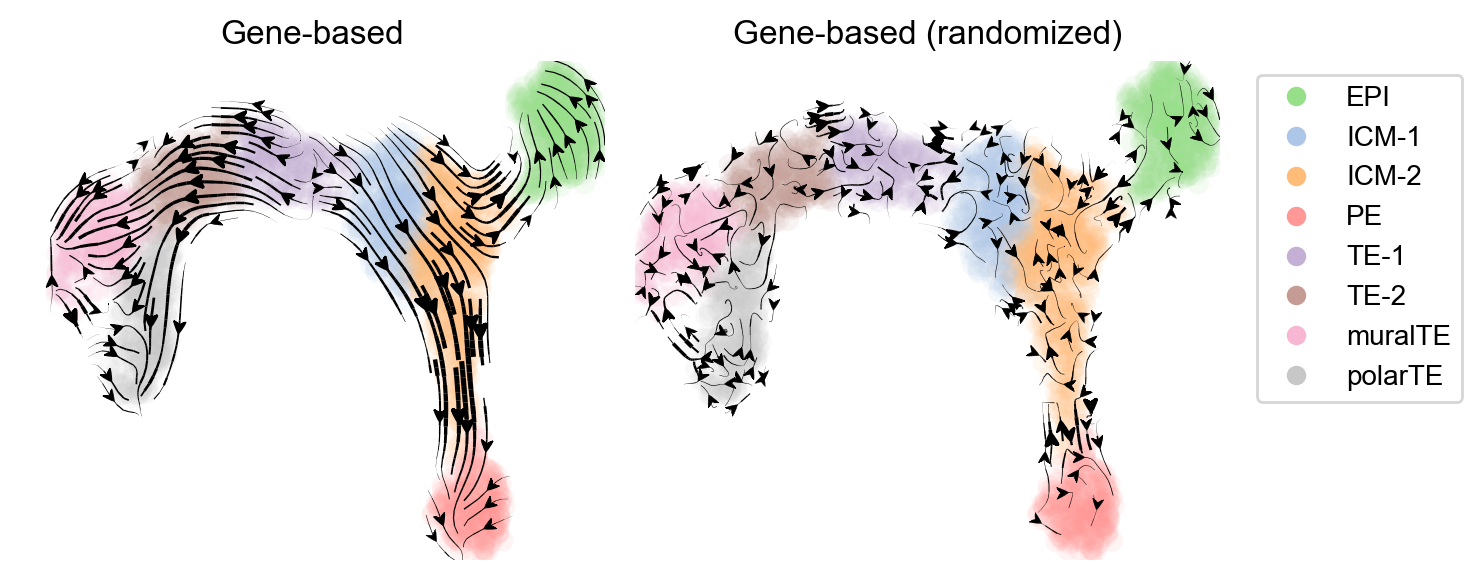

In [3]:
cmap = plt.colormaps["tab20"]
palette = {
    "ICM-1": cmap(1), 
    "ICM-2": cmap(3),
    "EPI": cmap(5),
    "PE": cmap(7),
    "TE-1": cmap(9),
    "TE-2": cmap(11),
    "muralTE": cmap(13),
    "polarTE": cmap(15)
}

color = "CellType"
pointsize = 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3))
dyn.pl.streamline_plot(adata, color=color, color_key=palette, pointsize=pointsize, ax=ax1, basis='umap', save_show_or_return='return', show_legend=False)
dyn.pl.streamline_plot(adata, color=color, color_key=palette, pointsize=pointsize, ax=ax2, basis='umap_rnd', save_show_or_return='return', show_legend="right")
ax1.set_title("Gene-based")
ax2.set_title("Gene-based (randomized)")
plt.tight_layout()

plt.savefig("figures/streamline_plot.gene_based.scanpy_umap.png", dpi=300)
plt.show()
plt.close()